In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Save model
import joblib

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Y2038_Enhanced_Dataset.xlsx to Y2038_Enhanced_Dataset.xlsx


In [ ]:
df = pd.read_excel("Y2038_Enhanced_Dataset.xlsx")

In [ ]:
df.head()

,S.No,Pattern,Language,Risk,Label,Explanation
0,1,int timestamp = time(NULL);,C,High,UNSAFE,"Stores Unix time in a 32-bit integer, may over..."
1,2,time_t timestamp = time(NULL);,C,Low,SAFE,Uses time_t; safe on 64-bit time_t systems.
2,3,long long timestamp = (long long)time(NULL);,C,Low,SAFE,64-bit timestamp storage.
3,4,int expiry = time(NULL)+86400;,C,High,UNSAFE,Future timestamp in int.
4,5,uint64_t currentTime=(uint64_t)time(NULL);,C,Low,SAFE,64-bit timestamp.


In [ ]:
df.shape

(604, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   S.No         604 non-null    int64 
 1   Pattern      604 non-null    object
 2   Language     604 non-null    object
 3   Risk         604 non-null    object
 4   Label        604 non-null    object
 5   Explanation  604 non-null    object
dtypes: int64(1), object(5)
memory usage: 28.4+ KB


In [ ]:
df.isnull().sum()

,0
S.No,0
Pattern,0
Language,0
Risk,0
Label,0
Explanation,0


In [ ]:
df.columns

Index(['S.No', 'Pattern', 'Language', 'Risk', 'Label', 'Explanation'], dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Risk"].value_counts()

,count
Risk,
Low,292
High,193
Medium,119


In [ ]:
df["Language"].value_counts()

,count
Language,
Java,362
C,189
C++,53


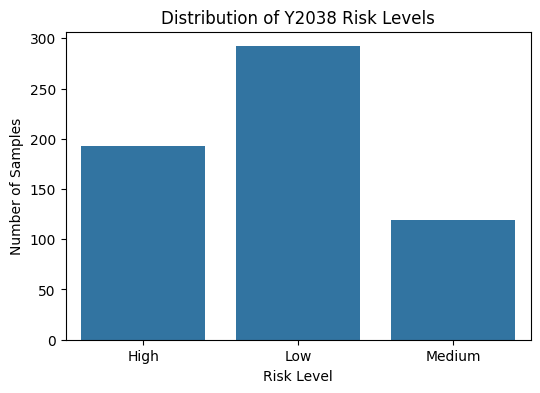

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Risk")

plt.title("Distribution of Y2038 Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
df["Risk"].value_counts()

,count
Risk,
Low,292
High,193
Medium,119


In [ ]:
df["Language"].value_counts()

,count
Language,
Java,362
C,189
C++,53


In [ ]:
df["Code"] = df["Language"] + " " + df["Pattern"]

In [ ]:
X = df["Code"]
y = df["Risk"]

In [ ]:
print(X.head())

0                     C int timestamp = time(NULL);
1                  C time_t timestamp = time(NULL);
2    C long long timestamp = (long long)time(NULL);
3                  C int expiry = time(NULL)+86400;
4      C uint64_t currentTime=(uint64_t)time(NULL);
Name: Code, dtype: object


In [ ]:
print(y.head())

0    High
1     Low
2     Low
3    High
4     Low
Name: Risk, dtype: object


In [ ]:
print(y.value_counts())

Risk
Low       292
High      193
Medium    119
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 483
Testing samples: 121


In [ ]:
print("Training distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training distribution:
Risk
Low       234
High      154
Medium     95
Name: count, dtype: int64

Testing distribution:
Risk
Low       58
High      39
Medium    24
Name: count, dtype: int64


In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [ ]:
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (483, 355)
Testing TF-IDF shape: (121, 355)


In [ ]:
model = LinearSVC(random_state=42)

In [ ]:
model.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
print(y_pred[:10])

['Medium' 'Low' 'Low' 'High' 'Low' 'Low' 'High' 'Low' 'Low' 'High']


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,Medium,Medium
1,Low,Low
2,Low,Low
3,High,High
4,Low,Low
5,Low,Low
6,High,High
7,Low,Low
8,Low,Low
9,High,High


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 95.87%


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.95      0.95      0.95        39
         Low       0.97      1.00      0.98        58
      Medium       0.95      0.88      0.91        24

    accuracy                           0.96       121
   macro avg       0.96      0.94      0.95       121
weighted avg       0.96      0.96      0.96       121



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[37  1  1]
 [ 0 58  0]
 [ 2  1 21]]


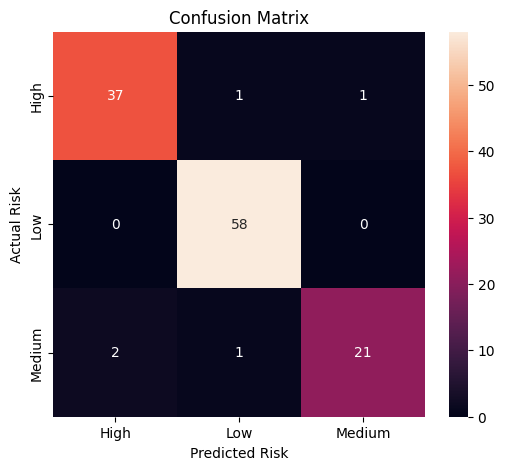

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 95.87%


In [ ]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n        High       0.95      0.95      0.95        39\n         Low       0.97      1.00      0.98        58\n      Medium       0.95      0.88      0.91        24\n\n    accuracy                           0.96       121\n   macro avg       0.96      0.94      0.95       121\nweighted avg       0.96      0.96      0.96       121\n'

In [ ]:
import joblib

In [ ]:
joblib.dump(model, "svm_model.pkl")

['svm_model.pkl']

In [ ]:
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [ ]:
from google.colab import files

files.download("svm_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>